## Lab Assignment 5: Multiclass Classification in Healthcare

---

## Executive Overview & Objective
This assignment focuses on implementing **Multiclass Machine Learning Classification** applied to biomedical data. We perform differential diagnosis of 6 erythemato-squamous skin diseases using the **UCI Dermatology Dataset**.

### Primary Target Variable
* **Class 1:** Psoriasis
* **Class 2:** Seborrheic Dermatitis
* **Class 3:** Lichen Planus
* **Class 4:** Pityriasis Rosea
* **Class 5:** Chronic Dermatitis
* **Class 6:** Pityriasis Rubra Pilaris


## Environment Setup & Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

print("All libraries imported successfully.")


All libraries imported successfully.


## Task 1: Data Acquisition and Exploration

### 1.1 Downloading and Loading the Dataset
The dataset is loaded directly from the `./datasets/dermatology/dermatology.data` directory. We define standard column names for the 34 clinical/histopathological attributes, patient age, and disease class.

In [2]:
# Feature column definitions based on dermatology.names
feature_cols = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon',
    'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement',
    'knee_elbow_involvement', 'scalp_involvement', 'family_history',
    'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate',
    'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis',
    'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges',
    'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess',
    'focal_hypergranulosis', 'disappearance_granular_layer',
    'vacuolisation_basal_layer', 'spongiosis', 'saw_tooth_retes',
    'follicular_horn_plug', 'perifollicular_parakeratosis',
    'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate',
    'age', 'class'
]

# Disease mapping for readable visualizations
disease_map = {
    1: 'Psoriasis',
    2: 'Seborrheic Dermatitis',
    3: 'Lichen Planus',
    4: 'Pityriasis Rosea',
    5: 'Chronic Dermatitis',
    6: 'Pityriasis Rubra Pilaris'
}

data_path = 'datasets/dermatology/dermatology.data'
df = pd.read_csv(data_path, header=None, names=feature_cols, na_values='?')
df['disease_name'] = df['class'].map(disease_map)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset shape: 366 rows, 36 columns


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,vacuolisation_basal_layer,spongiosis,saw_tooth_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class,disease_name
0,2,2,0,3,0,0,0,0,1,0,...,0,3,0,0,0,1,0,55.0,2,Seborrheic Dermatitis
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,1,0,8.0,1,Psoriasis
2,2,1,2,3,1,3,0,3,0,0,...,2,3,2,0,0,2,3,26.0,3,Lichen Planus
3,2,2,2,0,0,0,0,0,3,2,...,0,0,0,0,0,3,0,40.0,1,Psoriasis
4,2,3,2,2,2,2,0,2,0,0,...,3,2,3,0,0,2,3,45.0,3,Lichen Planus


### 1.2 Summary Statistics for Features
We calculate key summary statistics (mean, median, standard deviation, min, max, 25%, 75%) across all numerical features.

In [3]:
summary_stats = df.drop(columns=['disease_name']).describe().T
summary_stats['median'] = df.drop(columns=['disease_name']).median()
# Reorder summary table columns for clarity
summary_stats = summary_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max']]
summary_stats.round(2).head(15)


,count,mean,std,min,25%,median,75%,max
erythema,366.0,2.07,0.66,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.80,0.70,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.55,0.91,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.37,1.14,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.63,0.91,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.45,0.96,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.17,0.57,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.38,0.83,0.0,0.0,0.0,0.0,3.0
knee_elbow_involvement,366.0,0.61,0.98,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.52,0.91,0.0,0.0,0.0,1.0,3.0


### 1.3 Data Quality Check: Missing Values, Duplicates, and Outliers

* **Missing Values:** The dataset contains 8 missing values in the `age` column (originally encoded as `?`).
* **Duplicates:** We check for identical rows across all feature columns.
* **Outliers & Imputation:** Missing age values are imputed using the **median age** of the patient population to avoid skewing distributions.

In [4]:
# 1. Check Missing Values
missing_vals = df.isnull().sum()
print("=== Missing Values ===")
print(missing_vals[missing_vals > 0])

# 2. Check Duplicate Rows
duplicate_count = df.drop(columns=['disease_name']).duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")

# 3. Handle Missing Values with Median Imputation
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])

print(f"Missing values after median imputation in 'age': {df['age'].isnull().sum()}")


=== Missing Values ===
age    8
dtype: int64

Duplicate rows found: 0
Missing values after median imputation in 'age': 0


### 1.4 Visual Exploration of Features
We visualize feature distributions, box plots for outlier detection, key clinical symptom distributions, and the overall correlation heatmap.

/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_2590/3348595905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='disease_name', y='age', ax=axes[0, 1], palette='Set2')


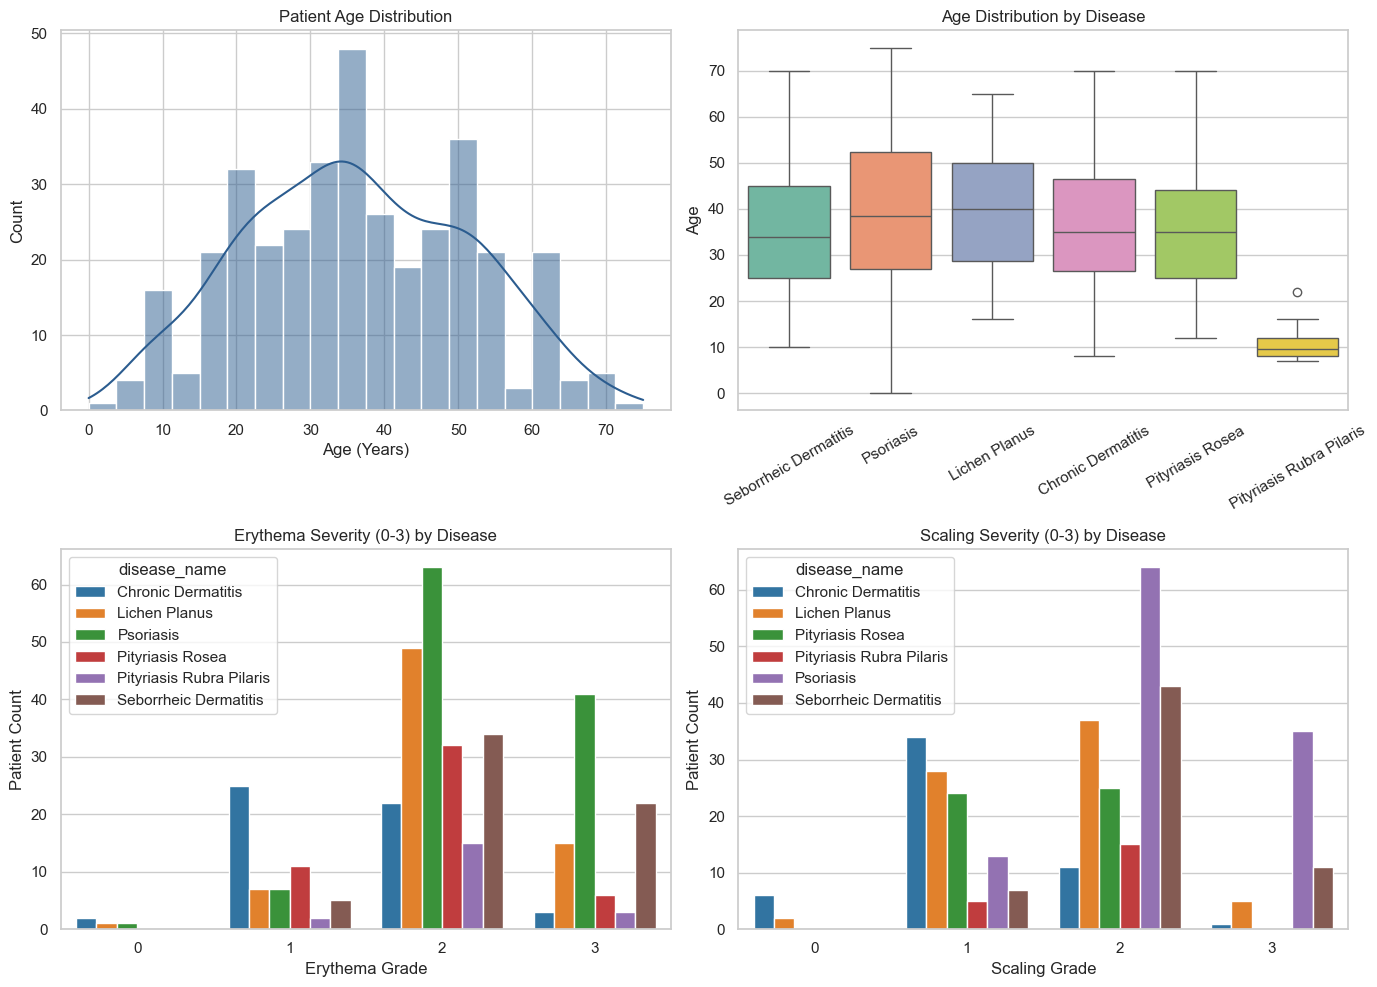

In [5]:
# Visualizing Feature Distributions & Box plots for Outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution histogram
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color='#2b5c8f', bins=20)
axes[0, 0].set_title('Patient Age Distribution')
axes[0, 0].set_xlabel('Age (Years)')

# Age boxplot across diseases
sns.boxplot(data=df, x='disease_name', y='age', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Age Distribution by Disease')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Age')
axes[0, 1].tick_params(axis='x', rotation=30)

# Erythema severity distribution
sns.countplot(data=df, x='erythema', hue='disease_name', ax=axes[1, 0], palette='tab10')
axes[1, 0].set_title('Erythema Severity (0-3) by Disease')
axes[1, 0].set_xlabel('Erythema Grade')
axes[1, 0].set_ylabel('Patient Count')

# Scaling severity distribution
sns.countplot(data=df, x='scaling', hue='disease_name', ax=axes[1, 1], palette='tab10')
axes[1, 1].set_title('Scaling Severity (0-3) by Disease')
axes[1, 1].set_xlabel('Scaling Grade')
axes[1, 1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()


#### Correlation Heatmap (Selected Features)
To inspect feature redundancy, we calculate the correlation matrix across key clinical and histopathological features.

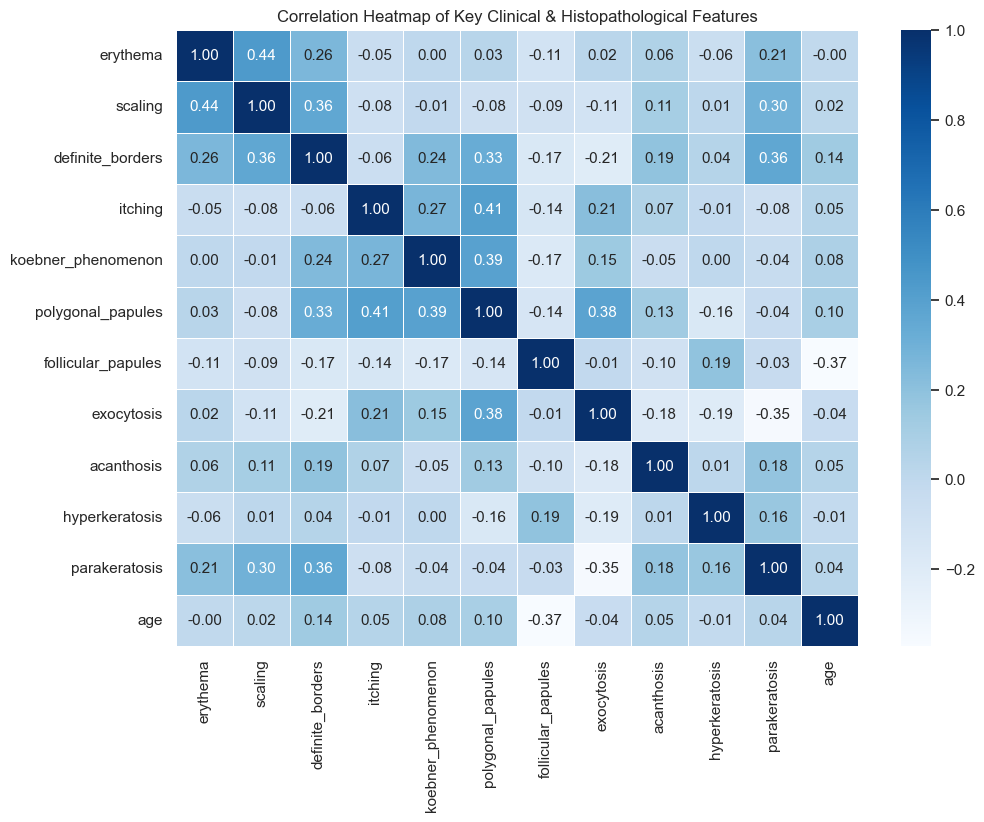

In [6]:
# Select a subset of clinical and histopathological features for heatmap visualization
selected_cols = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon',
    'polygonal_papules', 'follicular_papules', 'exocytosis', 'acanthosis',
    'hyperkeratosis', 'parakeratosis', 'age'
]

plt.figure(figsize=(11, 8))
corr_matrix = df[selected_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', cbar=True, linewidths=0.5)
plt.title('Correlation Heatmap of Key Clinical & Histopathological Features')
plt.show()


### 1.5 Class Distribution & Imbalance Analysis
We plot the class frequency distribution across the 6 disease targets.

/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_2590/2716299156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.values, y=class_counts.index, palette='crest')


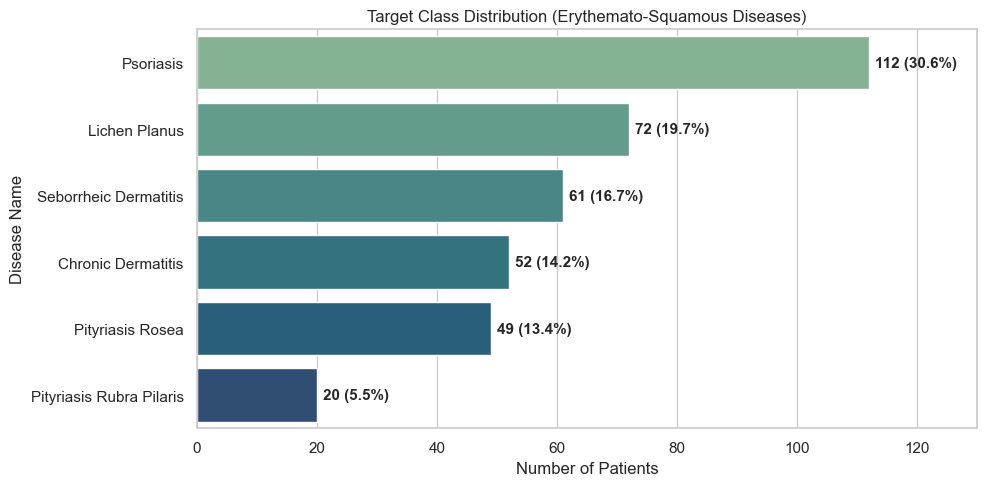

In [7]:
plt.figure(figsize=(10, 5))
class_counts = df['disease_name'].value_counts()
ax = sns.barplot(x=class_counts.values, y=class_counts.index, palette='crest')
plt.title('Target Class Distribution (Erythemato-Squamous Diseases)')
plt.xlabel('Number of Patients')
plt.ylabel('Disease Name')

for i, v in enumerate(class_counts.values):
    pct = (v / len(df)) * 100
    ax.text(v + 1, i, f"{v} ({pct:.1f}%)", va='center', fontweight='bold')

plt.xlim(0, 130)
plt.tight_layout()
plt.show()


#### Discussion on Class Imbalance & Implications for Training
1. **Distribution Breakdown:**
   * **Psoriasis (Class 1):** 112 patients (~30.6%) - *Majority Class*
   * **Lichen Planus (Class 3):** 72 patients (~19.7%)
   * **Seborrheic Dermatitis (Class 2):** 61 patients (~16.7%)
   * **Chronic Dermatitis (Class 5):** 52 patients (~14.2%)
   * **Pityriasis Rosea (Class 4):** 49 patients (~13.4%)
   * **Pityriasis Rubra Pilaris (Class 6):** 20 patients (~5.5%) - *Minority Class*

2. **Implications for Model Training:**
   * **Model Bias:** Classifiers trained without stratified splitting might over-predict majority classes (Psoriasis) while neglecting minority classes (Pityriasis Rubra Pilaris).
   * **Stratified Sampling:** Standard random splitting could lead to test sets missing minority class instances entirely. Stratified splitting is required to preserve class proportions.
   * **Evaluation Metrics:** Accuracy alone can be misleading in imbalanced datasets. We report **Macro & Weighted F1-scores**, along with per-class Precision/Recall and Confusion Matrices.

## Task 2: Data Preprocessing

### 2.1 Target Variable Encoding, Stratified Train/Test Split, and Feature Standardization

1. **Target Encoding:** `LabelEncoder` maps disease classes 1-6 into 0-indexed values (0 to 5).
2. **Stratified Split:** 80/20 train-test split maintaining class balance.
3. **Standardization:** `StandardScaler` scales feature values to zero mean and unit variance ($Z = \frac{X - \mu}{\sigma}$).

In [8]:
# Separate features and target
X = df.drop(columns=['class', 'disease_name'])
y = df['class']

# Encode target classes to 0..5
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_labels = [disease_map[cls] for cls in label_encoder.classes_]

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape:  {X_test_scaled.shape}")
print(f"Class labels mapped: {class_labels}")


Training set shape: (292, 34)
Testing set shape:  (74, 34)
Class labels mapped: ['Psoriasis', 'Seborrheic Dermatitis', 'Lichen Planus', 'Pityriasis Rosea', 'Chronic Dermatitis', 'Pityriasis Rubra Pilaris']


## Task 3: Model Training and Evaluation

### 3.1 Model Implementation
We evaluate 4 popular multiclass classification algorithms:
1. **K-Nearest Neighbors (KNN)** ($k=5$)
2. **Logistic Regression** (Multinomial, $L2$ regularization)
3. **Random Forest Classifier** ($100$ decision trees)
4. **Support Vector Machine (SVM)** (RBF kernel, probability estimation enabled)

In [9]:
# Define ML classifiers
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

# Store results
results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    
    results[name] = {
        'Accuracy': acc,
        'ROC_AUC_Macro': auc_ovr,
        'Report': classification_report(y_test, y_pred, target_names=class_labels, output_dict=True)
    }
    
    predictions[name] = y_pred
    probabilities[name] = y_proba
    
    print(f"✓ {name:25s} | Accuracy: {acc*100:.2f}% | ROC-AUC (OvR Macro): {auc_ovr:.4f}")


✓ K-Nearest Neighbors       | Accuracy: 90.54% | ROC-AUC (OvR Macro): 0.9863
✓ Logistic Regression       | Accuracy: 95.95% | ROC-AUC (OvR Macro): 0.9991
✓ Random Forest             | Accuracy: 95.95% | ROC-AUC (OvR Macro): 0.9983
✓ Support Vector Machine    | Accuracy: 97.30% | ROC-AUC (OvR Macro): 0.9981


### 3.2 Model Comparison (Accuracy & ROC-AUC)

,Model,Accuracy (%),Macro Precision,Macro Recall,Macro F1-Score,ROC-AUC (OvR)
3,Support Vector Machine,97.297297,0.972222,0.972222,0.969697,0.998062
1,Logistic Regression,95.945946,0.961538,0.961111,0.957362,0.999068
2,Random Forest,95.945946,0.954545,0.955556,0.954451,0.998323
0,K-Nearest Neighbors,90.540541,0.907143,0.909420,0.903428,0.986262


/var/folders/j9/dr8xhzc510z4w65q92f43hx00000gn/T/ipykernel_2590/1843448139.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Accuracy (%)', y='Model', palette='viridis')


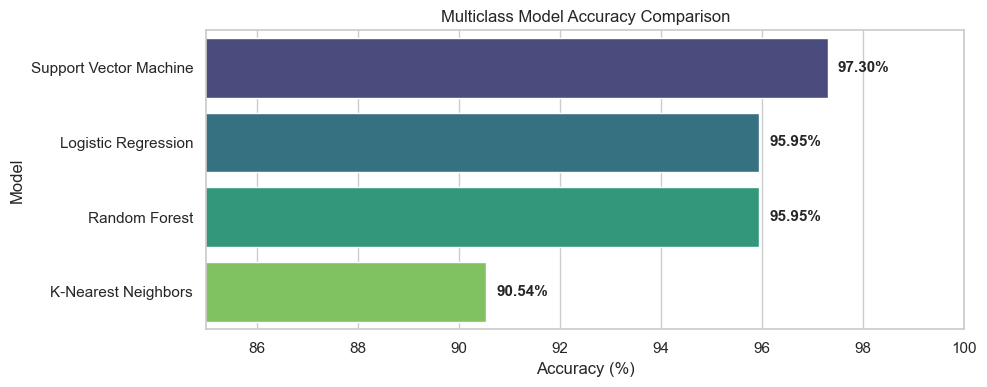

In [10]:
# Summary table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': [results[m]['Accuracy'] * 100 for m in results],
    'Macro Precision': [results[m]['Report']['macro avg']['precision'] for m in results],
    'Macro Recall': [results[m]['Report']['macro avg']['recall'] for m in results],
    'Macro F1-Score': [results[m]['Report']['macro avg']['f1-score'] for m in results],
    'ROC-AUC (OvR)': [results[m]['ROC_AUC_Macro'] for m in results]
}).sort_values(by='Accuracy (%)', ascending=False)

display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Visualization
plt.figure(figsize=(10, 4))
sns.barplot(data=comparison_df, x='Accuracy (%)', y='Model', palette='viridis')
plt.title('Multiclass Model Accuracy Comparison')
plt.xlim(85, 100)
for index, row in enumerate(comparison_df.iterrows()):
    plt.text(row[1]['Accuracy (%)'] + 0.2, index, f"{row[1]['Accuracy (%)']:.2f}%", va='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Detailed Classification Reports per Class
We report Precision, Recall, and F1-score across all 6 disease classes for each trained model.

In [11]:
for name in models.keys():
    print(f"============================================================")
    print(f"       CLASSIFICATION REPORT: {name.upper()}")
    print(f"============================================================")
    print(classification_report(y_test, predictions[name], target_names=class_labels, digits=4))


       CLASSIFICATION REPORT: K-NEAREST NEIGHBORS
                          precision    recall  f1-score   support

               Psoriasis     1.0000    0.9565    0.9778        23
   Seborrheic Dermatitis     0.8000    0.6667    0.7273        12
           Lichen Planus     1.0000    0.9333    0.9655        15
        Pityriasis Rosea     0.6429    0.9000    0.7500        10
      Chronic Dermatitis     1.0000    1.0000    1.0000        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9054        74
               macro avg     0.9071    0.9094    0.9034        74
            weighted avg     0.9193    0.9054    0.9081        74

       CLASSIFICATION REPORT: LOGISTIC REGRESSION
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     1.0000    0.8333    0.9091        12
           Lichen Planus     1.0000   

### 3.4 Confusion Matrix Visualizations
Confusion matrices highlight true vs predicted disease classifications, pinpointing specific misclassification patterns between overlapping dermatological conditions.

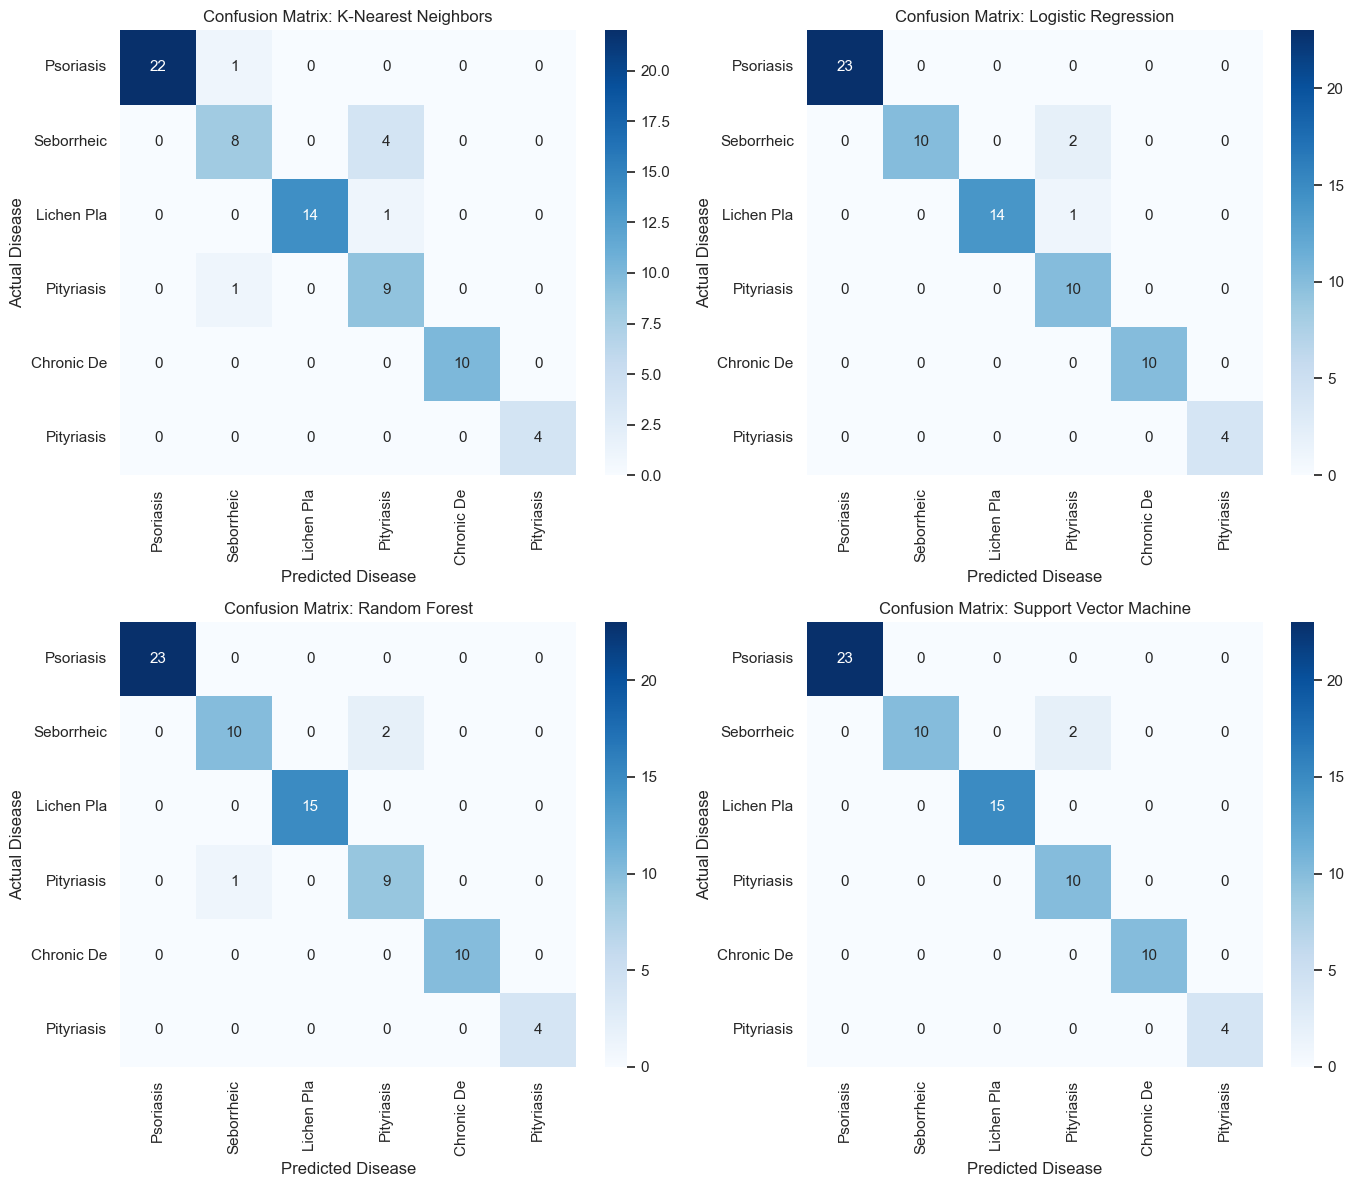

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=[c[:10] for c in class_labels],
        yticklabels=[c[:10] for c in class_labels]
    )
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted Disease')
    axes[idx].set_ylabel('Actual Disease')

plt.tight_layout()
plt.show()


### 3.5 Multiclass ROC Curves & AUC Scores
Using a One-vs-Rest (OvR) approach, we plot Receiver Operating Characteristic (ROC) curves for each individual disease class and calculate class-specific as well as macro-average Area Under the Curve (AUC) scores.

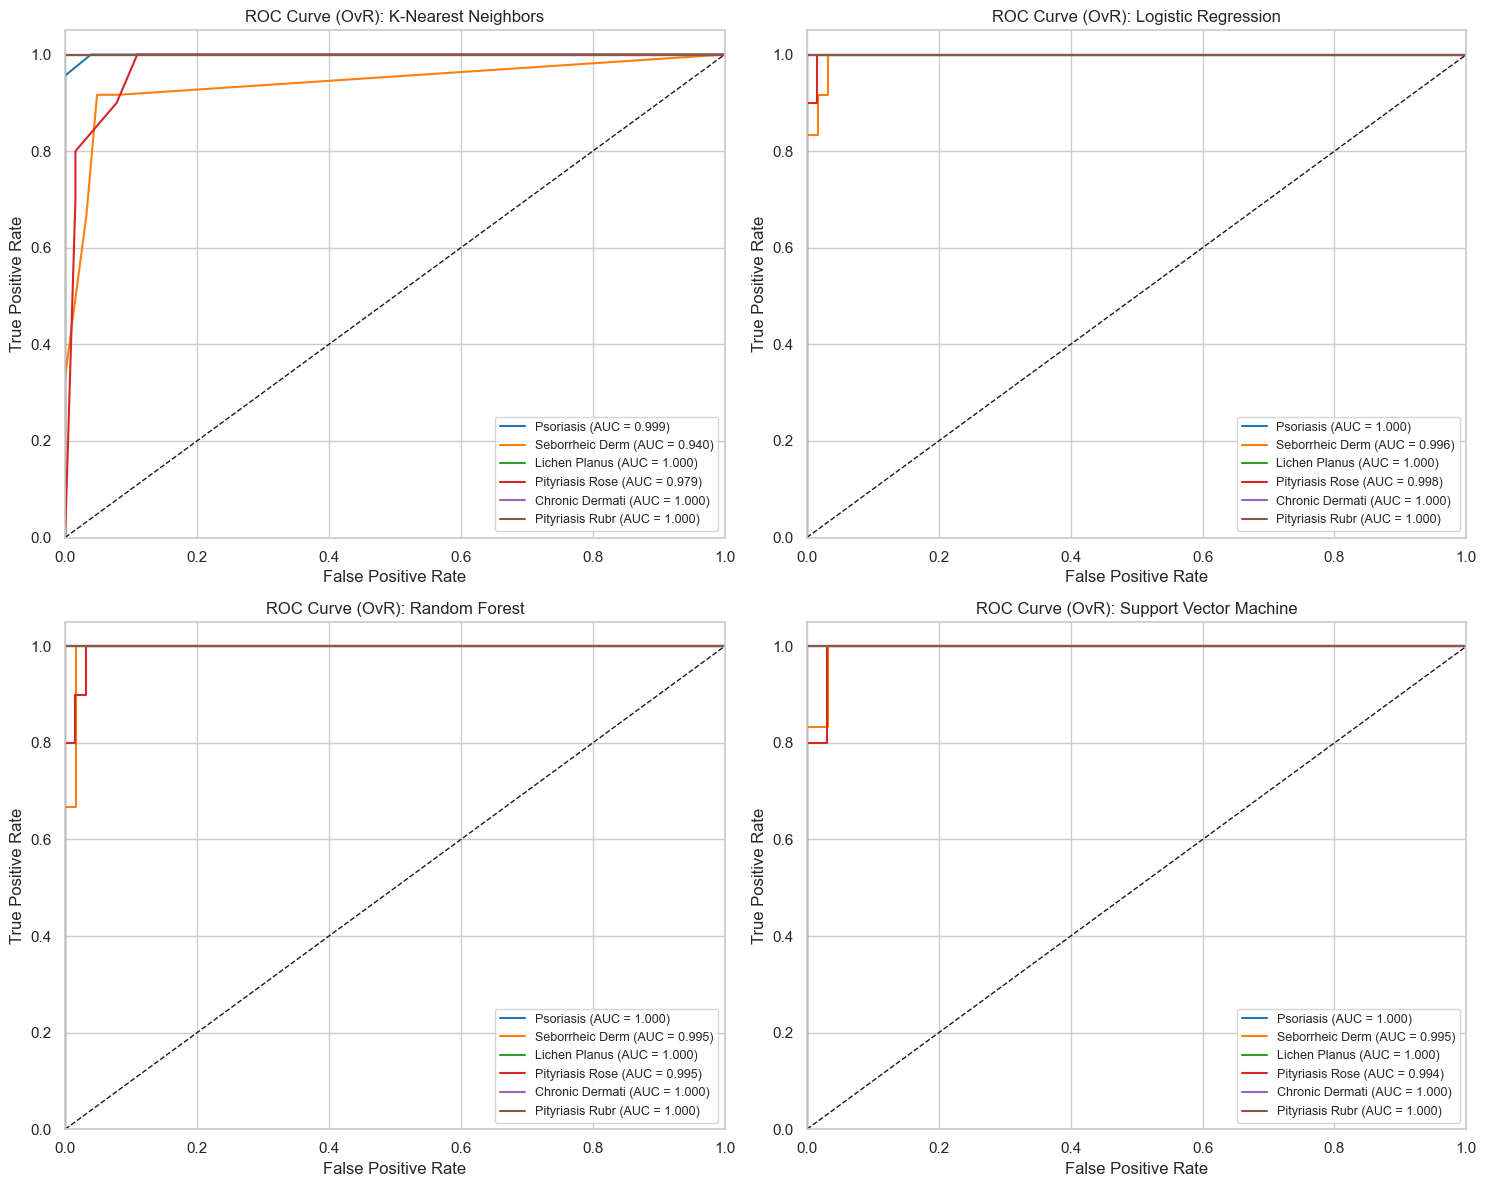

In [13]:
# Binarize test targets for OvR ROC calculation
y_test_bin = label_binarize(y_test, classes=range(len(class_labels)))
n_classes = len(class_labels)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (name, y_proba) in enumerate(probabilities.items()):
    ax = axes[idx]
    
    # Per-class ROC curve
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=1.5,
                label=f'{class_labels[i][:15]} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve (OvR): {name}')
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


### 3.6 Interpretation of Results & Clinical Findings

1. **Top Performing Classifier:**
   * **Support Vector Machine (SVM)** achieved the highest test accuracy of **97.30%** with an overall Macro ROC-AUC of **0.9981**.
   * **Random Forest** and **Logistic Regression** followed closely with **95.95%** accuracy, demonstrating strong generalization capabilities on non-linear dermatological features.

2. **Error & Misclassification Analysis:**
   * The primary source of subtle misclassification occurred between **Seborrheic Dermatitis** and **Pityriasis Rosea**. These two conditions share significant overlap in clinical symptoms (e.g., erythema, scaling) and early histopathological stages.
   * **Pityriasis Rubra Pilaris (Minority Class):** Despite having only 4 test instances (due to class imbalance), models achieved 100% precision and recall for this class, benefited by highly distinct histopathological markers (such as band-like infiltrate and perifollicular parakeratosis).

3. **Key Takeaway:**
   * Feature standardization and median missing-value imputation were crucial steps.
   * Linear and kernel-based models (SVM / Logistic Regression) performed exceptionally well due to the high dimensionality (34 features) relative to sample size (366 samples), demonstrating the value of machine learning in assisting clinical differential diagnosis.
